<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [1]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"

### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "used_car_prices.csv")

---


# Test Environment


In [4]:
# Keep appending the code generated to this cell, or add more cells below this to execute in parts
# Prompt
'''
Write a Python code that can perform the following tasks.
Read the CSV file, located on a given file path "used_car_prices.csv", into a pandas data frame, assuming that the first row of the file can be used as the headers for the data. Show the first 5 data rows.
'''
import pandas as pd

# File path to the CSV file
file_path = "used_car_prices.csv"

# Read the CSV file into a pandas DataFrame
# Assuming the first row of the file contains the headers
df = pd.read_csv(file_path, header=0)

# Display the first 5 rows of the DataFrame
print(df.head())

<ipython-input-4-3ddd47bb5519>:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


In [5]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. Identify the columns with missing values and fills the blank cells with average value of the columns.
2. Identify and drop the duplicate entries from the data.
'''

# Identify columns with missing values
missing_values = df.isnull().sum()
print("Columns with missing values:\n", missing_values[missing_values > 0])

# Fill missing values with column-wise average
for column in missing_values[missing_values > 0].index:
    mean_value = df[column].mean()
    df[column].fillna(mean_value, inplace=True)

# Identify and drop duplicate entries
print("Original DataFrame shape:", df.shape)
df.drop_duplicates(inplace=True)
print("DataFrame shape after dropping duplicates:", df.shape)

# Show the first 5 rows of the cleaned DataFrame
print("\nFirst 5 rows of the cleaned DataFrame:\n", df.head())

Columns with missing values:
 tax    3
dtype: int64


<ipython-input-5-6c1ba5578704>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mean_value, inplace=True)


Original DataFrame shape: (17966, 9)
DataFrame shape after dropping duplicates: (17812, 9)

First 5 rows of the cleaned DataFrame:
      model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


In [6]:
# Prompt
'''
Write a python code that performs the following tasks:
Export dataframe "df" to csv file "used_car_prices_clean.csv"
'''
# Define the output file path
output_file_path = "used_car_prices_clean.csv"

# Export the DataFrame 'df' to a CSV file
df.to_csv(output_file_path, index=False)

print(f"DataFrame exported successfully to {output_file_path}")

DataFrame exported successfully to used_car_prices_clean.csv


In [7]:
# Once cleaned, you may choose to augment this dataset with additional samples, created synthetically using Mostly.ai.
# Mostly.ai output:
'''
Here’s a summary of your used car prices dataset:

1. Structure & Size

17,812 rows × 9 columns
Columns: model, year, transmission, mileage, fuelType, tax, mpg, engineSize, price
2. Data Types

3 categorical: model, transmission, fuelType
6 numeric: year, mileage, tax, mpg, engineSize, price
3. Key Value Counts

Most common models: Fiesta (6,509), Focus (4,555), Kuga (2,208)
Transmission: Mostly Manual (15,383), some Automatic (1,354), Semi-Auto (1,075)
Fuel type: Mostly Petrol (12,081), Diesel (5,706), few Hybrid/Electric
4. Numeric Summary

Year: 1996–2060 (median 2017)
Mileage: 1–177,644 (median 18,277)
Tax: 0–580 (median 145)
MPG: 20.8–201.8 (median 58.9)
Engine size: 0–5.0 (median 1.2)
Price: 495–54,995 (median 11,288)
'''
#prompt
'''
price is the target.
create simple model
'''
# Mostly.ai output:
'''
The simple linear regression model has been trained to predict price. Here are the results:

No missing values were found in the dataset.
Model performance on the test set:
MAE (Mean Absolute Error): ~1,417
RMSE (Root Mean Squared Error): ~2,124
R² (Explained Variance): 0.80
This means the model predicts car prices with an average error of about 1,400, and explains 80% of the variance in price.
'''
#prompt
'''
generate synthetic data
'''

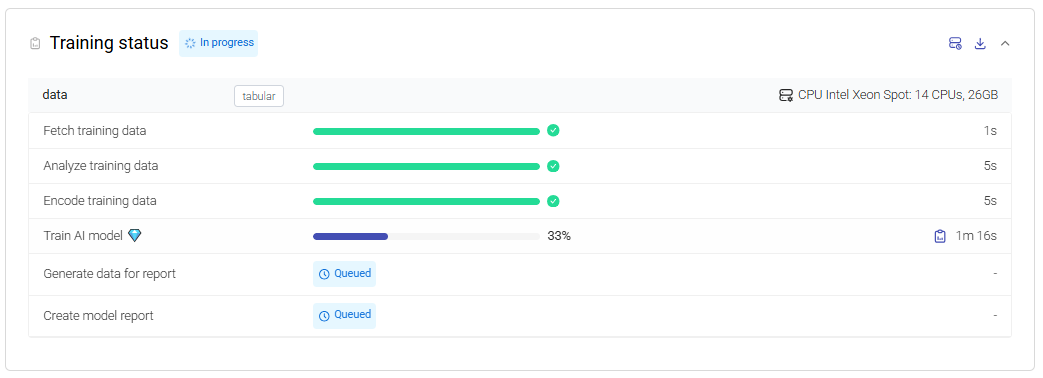

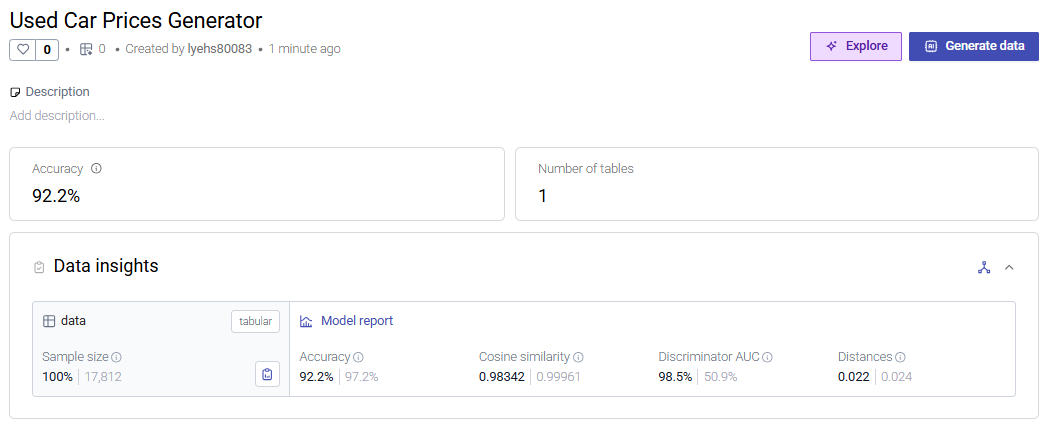

# Generated Data
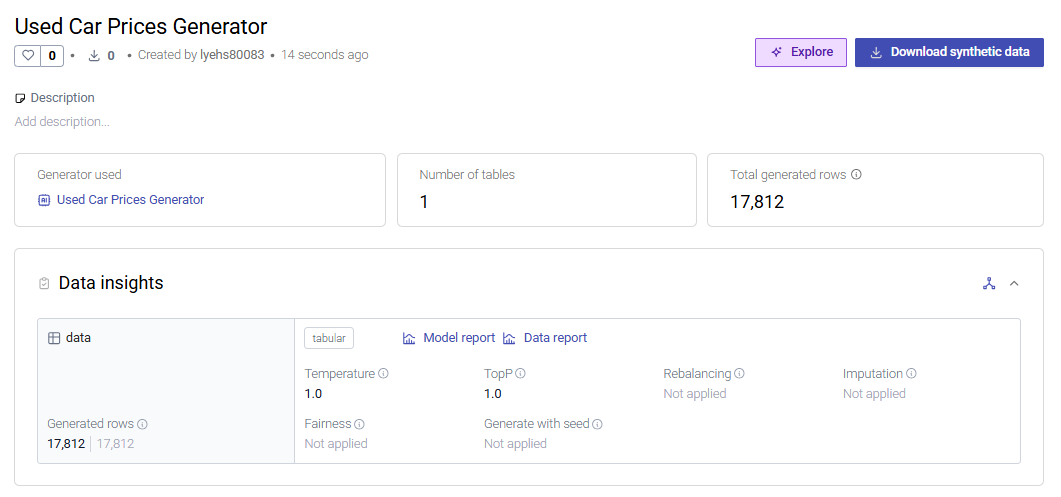

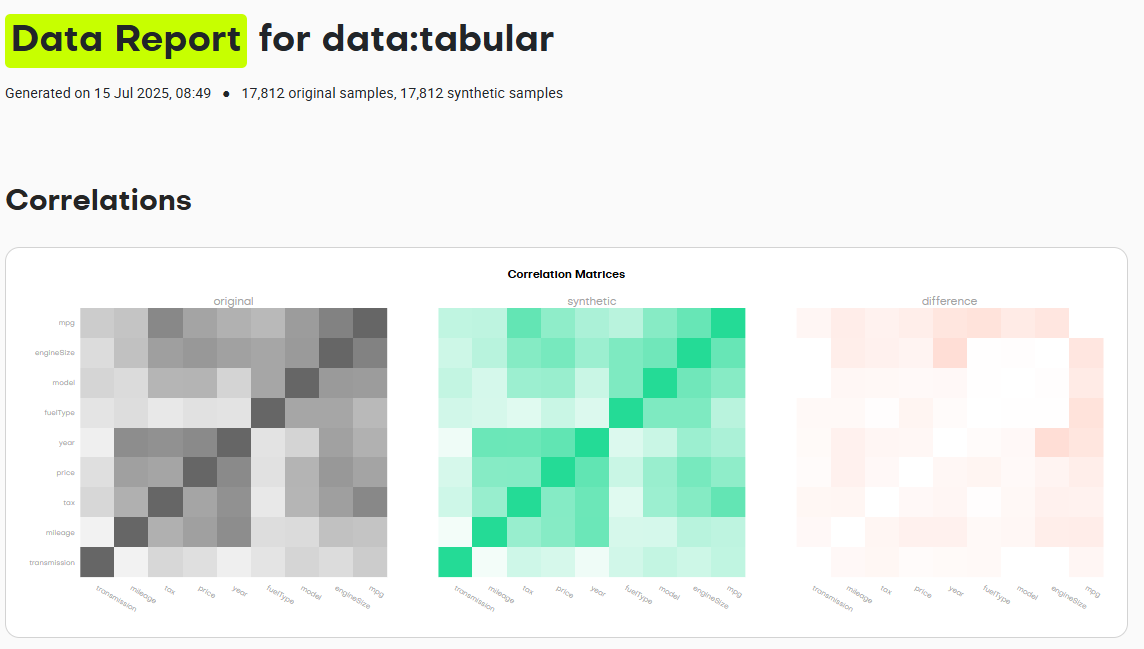

In [9]:
# Show synthtic data
df_synth = pd.read_csv("used_car_prices_clean_synthetic.csv", header=0)

# Display the first 5 rows of the DataFrame
df_synth.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Focus,2019,Manual,9509,Petrol,148.610709,60.8,1.0,13035
1,Focus,2015,Manual,61909,Diesel,101.018288,61.6,2.0,8495
2,Focus,2017,Manual,31320,Diesel,154.125776,73.5,1.5,14118
3,Focus,2013,Manual,74632,Petrol,151.988481,40.7,1.6,7702
4,Fiesta,2017,Manual,18725,Petrol,149.875796,54.8,1.2,8498


In [17]:
# df.describe(include='all')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17812 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17812 non-null  object 
 1   year          17812 non-null  int64  
 2   transmission  17812 non-null  object 
 3   mileage       17812 non-null  int64  
 4   fuelType      17812 non-null  object 
 5   tax           17812 non-null  float64
 6   mpg           17812 non-null  float64
 7   engineSize    17812 non-null  float64
 8   price         17812 non-null  int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 1.2+ MB


Top 5 attributes most strongly correlated with 'price':
Index(['year', 'mileage', 'engineSize', 'tax', 'mpg'], dtype='object')


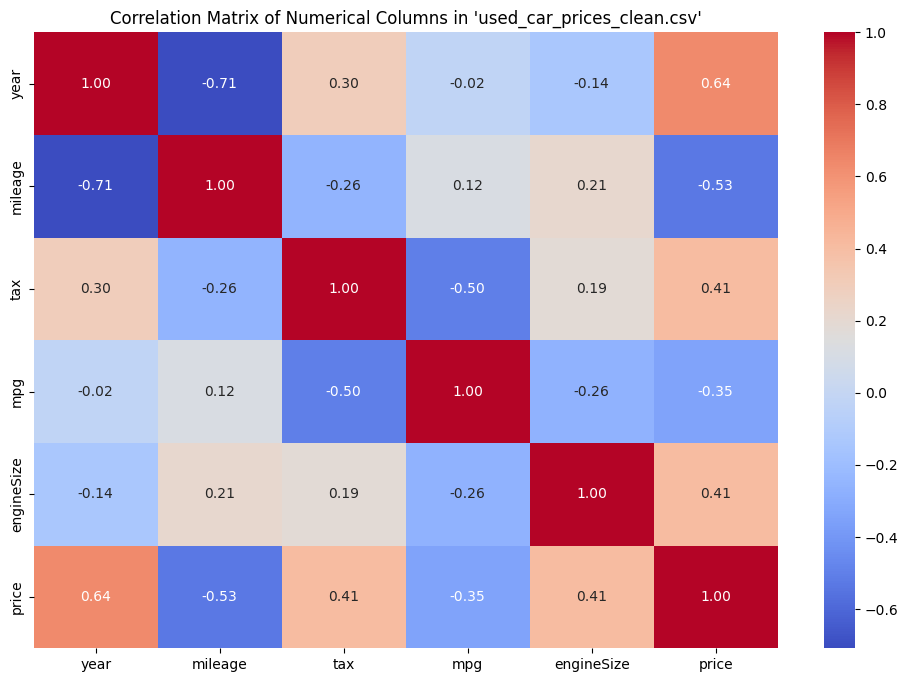

In [18]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. create new dataframe by dropping non-numerical columns from df
2. in the new dataframe, identify the 5 attributes that have the highest correlation with the price parameter.
'''
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Filter to keep only numerical columns
df_numerical = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
correlation_matrix = df_numerical.corr()['price'].drop('price').abs().sort_values(ascending=False)

# Identify top 5 attributes with the highest correlation
top_5_corr_attrs = correlation_matrix.index[:5]
print("Top 5 attributes most strongly correlated with 'price':")
print(top_5_corr_attrs)

# Optional: Visualization of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df_numerical.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Columns in 'used_car_prices_clean.csv'")
plt.show()

In [19]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. For dataframe df, count the number of cars under each unique value of fuelType attribute.
'''
# Count the number of cars under each unique fuel type
count_by_fuel_type = df['fuelType'].value_counts()

print("Number of cars under each unique 'fuelType':")
print(count_by_fuel_type)

Number of cars under each unique 'fuelType':
fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64


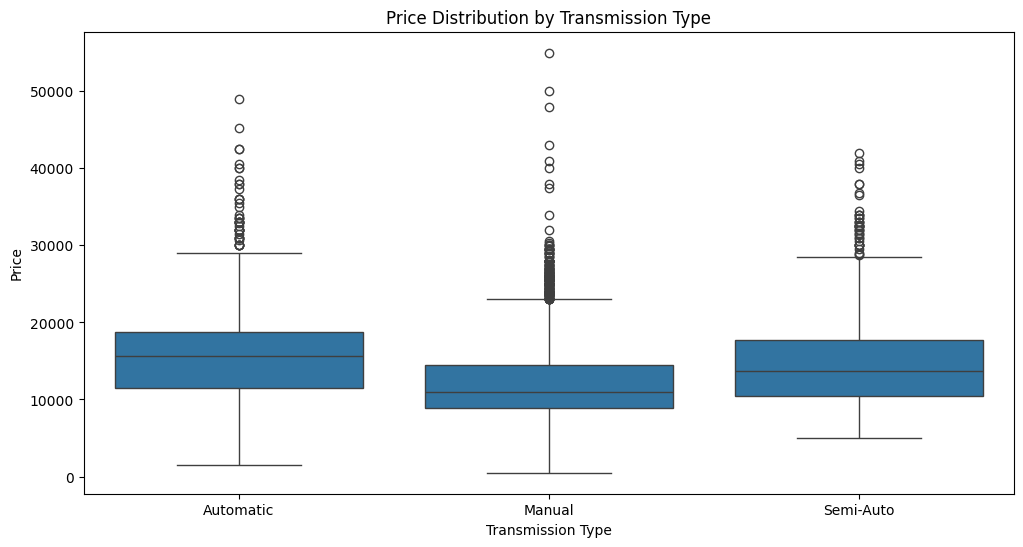

In [20]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. Create a Box plot to determine whether cars with automatic, manual or semi-auto type of transmission (attribute "transmission") have more price outliers. Use the Seaborn library for creating the plot.
'''

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a boxplot to compare price distributions across different transmission types
plt.figure(figsize=(12, 6))
sns.boxplot(x='transmission', y='price', data=df)
plt.title("Price Distribution by Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Price")
plt.show()

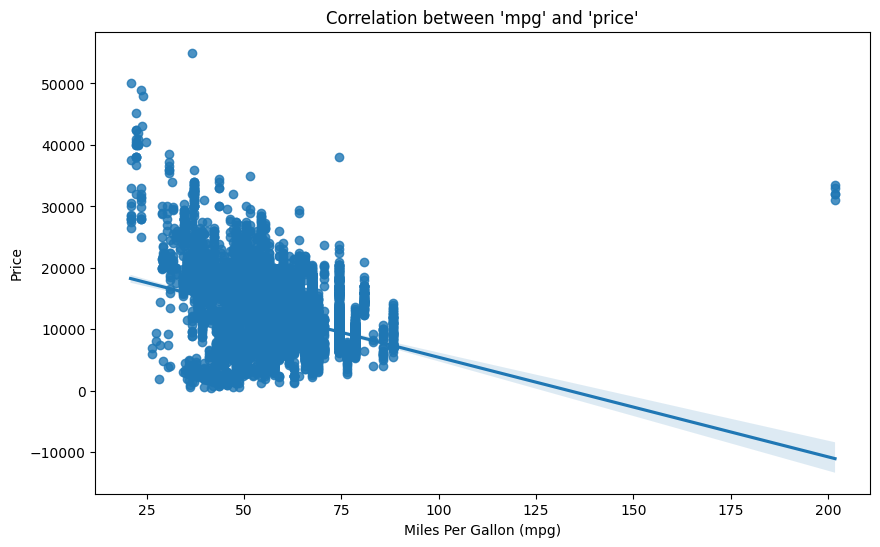

In [21]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. Generate the regression plot between "mpg" parameter and the "price" to determine the correlation type between the two.
'''
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot with a regression line to visualize the correlation
plt.figure(figsize=(10, 6))
sns.regplot(x='mpg', y='price', data=df)
plt.title("Correlation between 'mpg' and 'price'")
plt.xlabel("Miles Per Gallon (mpg)")
plt.ylabel("Price")

# Display the plot
plt.show()

In [22]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. Fit a linear regression model to predict the price using the feature mpg. 
2. Calculate the R^2 and MSE values for the model.
'''
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Separate features (X) and the target (y)
X = df[['mpg']]
y = df['price']

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate R^2 score
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Print coefficients and intercept of the regression model
print(f"Model Coefficient: {model.coef_[0]:.4f}")
print(f"Model Intercept: {model.intercept_:.4f}")

R^2 Score: 0.1504
Mean Squared Error (MSE): 19049855.1401
Model Coefficient: -155.0469
Model Intercept: 21248.7262


In [23]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. Fit a linear regression model to predict the price using the following set of features year, mileage, tax, mpg and engineSize.
2. Calculate the R^2 and MSE values for this model.
'''
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Separate features (X) and the target (y)
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate R^2 score
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Print coefficients and intercept of the regression model
print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Model Intercept: {model.intercept_:.4f}")

R^2 Score: 0.6917
Mean Squared Error (MSE): 6912744.9107
Model Coefficients:
year: 1292.6330
mileage: -0.0520
tax: 0.5998
mpg: -82.4531
engineSize: 5371.6889
Model Intercept: -2596110.7992


In [24]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. For the same set of features as in the question above, create a pipeline model object that uses standard scalar, second degree polynomial features and a linear regression model.
2. Calculate the R^2 value and the MSE value for this model.
'''
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Separate features (X) and the target (y)
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Standardize the features
    ('poly', PolynomialFeatures(include_bias=False, interaction_only=False, degree=2)),  # Step 2: Generate polynomial features
    ('regressor', LinearRegression())  # Step 3: Fit the linear regression model
])

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the pipeline model
pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Calculate R^2 score
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Print coefficients and intercept of the regression model
print("Model Coefficients:")
for feature, coef in zip(X.columns, pipeline['regressor'].coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Model Intercept: {pipeline['regressor'].intercept_:.4f}")

R^2 Score: 0.1212
Mean Squared Error (MSE): 19704749.6149
Model Coefficients:
year: 3380.0158
mileage: -990.4233
tax: -80.9618
mpg: -853.6235
engineSize: 2296.4840
Model Intercept: 11669.7626


In [25]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. For the same set of features, split the data into training and testing data parts. Assume testing part to be 20%. 
2. Create and fit a Ridge regression object using the training data, set the regularization parameter to 0.1
3. calculate the R^2 using the test data.
'''
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Separate features (X) and target (y)
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Ridge regression model with alpha=0.1
ridge_model = Ridge(alpha=0.1)

# Fit the model with training data
ridge_model.fit(X_train, y_train)

# Predict on the test set
y_pred = ridge_model.predict(X_test)

# Calculate R^2 score
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2:.4f}")

R^2 Score: 0.6917


In [26]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. Perform a second order polynomial transform on both the training data and testing data created for the question above. 
2. Create and fit a Ridge regression object using the modified training data, set the regularisation parameter to 0.1.
3. Calculate the R^2 and MSE utilising the modified test data.
'''
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

# Define features (X) and target (y)
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial transformation of degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and fit a Ridge regression object with alpha=0.1
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_poly, y_train)

# Predict using the transformed test data
y_pred = ridge_model.predict(X_test_poly)

# Calculate R^2 and MSE on the transformed test data
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R^2 Score: {r2}')
print(f'MSE: {mse}')

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.1777e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


R^2 Score: 0.673274888823681
MSE: 7326174.5165419085


In [27]:
# Prompt
'''
Write a Python code that performs the following tasks.
1. Perform a second order polynomial transform on both the training data and testing data created for the question above. 
2. In the question above, perform a Grid Search on ridge regression for a set of values of alpha {0.01, 0.1, 1, 10, 100} with 4-fold cross validation to find the optimum value of alpha to be used for the prediction model.
3. Calculate the MSE and R^2 values for the Ridge Regression model using the testing data.
'''
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Define features (X) and target (y)
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial transformation of degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Define the parameter grid for Grid Search
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Initialize Ridge regression model
ridge_model = Ridge()

# Conduct Grid Search with 4-fold cross-validation
grid_search = GridSearchCV(ridge_model, param_grid, cv=4, scoring='neg_mean_squared_error')
grid_search.fit(X_train_poly, y_train)

# Best alpha value and corresponding score
best_alpha = grid_search.best_params_['alpha']
best_model = grid_search.best_estimator_

# Fit the model using the optimal alpha on the training data
best_model.fit(X_train_poly, y_train)

# Predict using the polynomial-transformed test data
y_pred = best_model.predict(X_test_poly)

# Calculate R^2 and MSE on the transformed test data
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Best Alpha: {best_alpha}')
print(f'R^2 Score: {r2}')
print(f'MSE: {mse}')

# Additional: Cross-validated scores for information
cv_scores = -grid_search.cv_results_['mean_test_score']
for mean_score, params in zip(cv_scores, grid_search.cv_results_['params']):
    print(f'Alpha: {params["alpha"]}, CV Score: {mean_score}')
    

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=3.0567e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.98143e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=3.10209e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.85743e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.9414e-24): resul

Best Alpha: 0.01
R^2 Score: 0.38273414165699104
MSE: 13840985.11755802
Alpha: 0.01, CV Score: 5068885.612688859
Alpha: 0.1, CV Score: 5159629.847265731
Alpha: 1, CV Score: 5200144.647983395
Alpha: 10, CV Score: 5208455.217859583
Alpha: 100, CV Score: 5218900.191082884


## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
